In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('..'))
import torch

from utils_mounir import calc_perturbations, ponderation_predictor, get_y
from config_mounir import NearOODFramework, FarOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

- Charger les MSPs 
- Calculer les perturbations
- pondérer les MSPs par modalité pour avoir un nouveau score
- Prédire
- Valider

# Pondération simple en fonction de la perturbation

React, near ood vf, dataset UCF

In [ ]:
framework = NearOODFramework()
dataset_id, dataset_ood = framework.get_confs("id", "react")["UCF"], framework.get_confs("ood","react")["UCF"]

vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
perturbations_id = np.array([calc_perturbations(vecteur_sans_id, vecteur_avec) for vecteur_avec in confs_modalites_id.transpose()])
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
perturbations_ood = np.array([calc_perturbations(vecteur_sans_ood, vecteur_avec) for vecteur_avec in confs_modalites_ood.transpose()])
# shape : [N_modalités,]

In [7]:
scores_id = ponderation_predictor(confs_modalites_id, perturbations_id)
print(scores_id)
scores_id.mean()

[[4.3831897e-05]
 [4.3793669e-05]
 [4.3833454e-05]
 ...
 [4.3833505e-05]
 [4.3831576e-05]
 [4.3820524e-05]]


4.351701e-05

In [8]:
scores_ood = ponderation_predictor(confs_modalites_ood, perturbations_ood)
print(scores_ood)
scores_ood.mean()

[[0.0025928 ]
 [0.00347324]
 [0.002454  ]
 ...
 [0.00259482]
 [0.00087698]
 [0.00089622]]


0.0024703227

Evaluation

In [9]:
scores = np.vstack((scores_id, scores_ood))
labels = get_y(dataset_id, dataset_ood)
auroc, _, _, fpr = auc_and_fpr_recall(scores, labels, tpr_th=0.95)
print("AUC ROC: {}\nFPR@TPR95: {}\n".format(auroc.round(4), fpr.round(4)))

AUC ROC: 1.0
FPR@TPR95: 0.0



# Pondération avec une constante fois la perturbation

Near OOD VFA avec React n'a pas fonctionné en simple, je vais essayer de trouver une meilleure manière

# Inspection des résultats

scores_id.mean()=0.004878069, scores_id.var()=8.4371374e-07
scores_ood.mean()=0.0020456905, scores_ood.var()=2.2138468e-07
AUC ROC: 0.0072
FPR@TPR95: 1.0



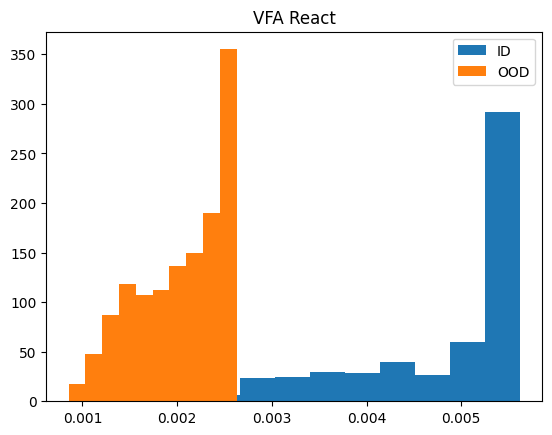

In [ ]:
framework = NearOODFramework("vfa")
dataset_id, dataset_ood = framework.get_confs("id", "react"), framework.get_confs("ood","react")

vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
perturbations_id = np.array([calc_perturbations(vecteur_sans_id, vecteur_avec) for vecteur_avec in confs_modalites_id.transpose()])
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
perturbations_ood = np.array([calc_perturbations(vecteur_sans_ood, vecteur_avec) for vecteur_avec in confs_modalites_ood.transpose()])
# shape : [N_modalités,]



scores_id = ponderation_predictor(confs_modalites_id, perturbations_id)
scores_ood = ponderation_predictor(confs_modalites_ood, perturbations_ood)
print(f"{scores_id.mean()=}, {scores_id.var()=}")
print(f"{scores_ood.mean()=}, {scores_ood.var()=}")

scores = np.vstack((scores_id, scores_ood))
labels = get_y(dataset_id, dataset_ood)
auroc, _, _, fpr = auc_and_fpr_recall(scores, labels, tpr_th=0.95)
print("AUC ROC: {}\nFPR@TPR95: {}\n".format(auroc.round(4), fpr.round(4)))

plt.hist(scores_id, label="ID")
plt.hist(scores_ood, label="OOD")
plt.title("VFA React")
_ = plt.legend()

p

scores_id.mean()=4.351701e-05, scores_id.var()=4.9117242e-12
scores_ood.mean()=0.0024703227, scores_ood.var()=8.2629555e-07
AUC ROC: 1.0
FPR@TPR95: 0.0



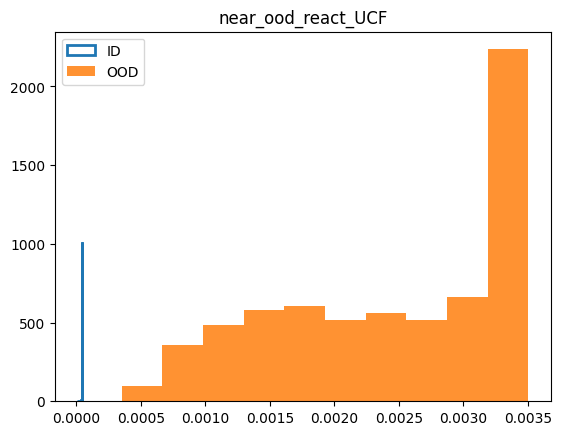

In [4]:
tester = PonderationTester(NearOODFramework("near_ood"), "react", "UCF")
tester.test_report(ponderation_predictor, plot_ood=True)

scores_id.mean()=0.93826467, scores_id.var()=0.020004073
scores_ood.mean()=0.46260262, scores_ood.var()=0.06357415
AUC ROC: 0.054
FPR@TPR95: 1.0



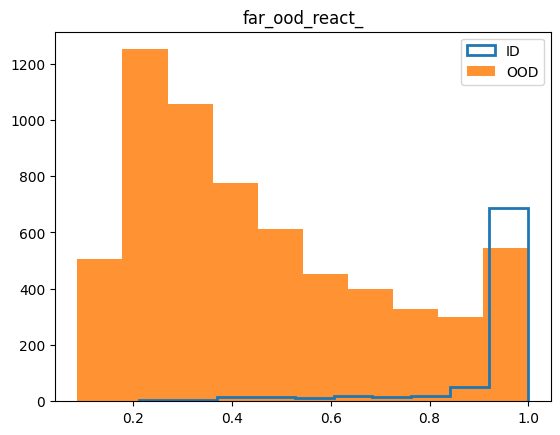

In [9]:
tester = PonderationTester(FarOODFramework(), "react")
tester.get_scores(ponderation_predictor)
#tester.separabilite(tester.scores)
#tester.separabilite({"id":tester.dataset_id[:,0].reshape(-1,1), "ood":tester.dataset_ood[:,0].reshape(-1,1)}, plot_ood=True)
tester.separabilite({"id":tester.dataset_id[:,1].reshape(-1,1), "ood":tester.dataset_ood[:,1].reshape(-1,1)}, plot_ood=True)

scores_id.mean()=4.351701e-05, scores_id.var()=4.9117242e-12
scores_ood.mean()=0.0024703227, scores_ood.var()=8.2629555e-07
AUC ROC: 1.0
FPR@TPR95: 0.0



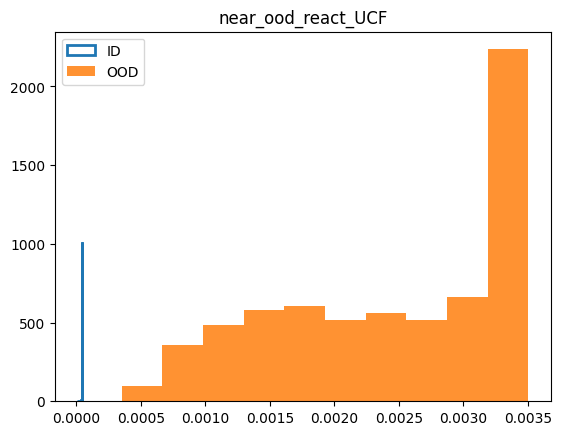

In [64]:
tester = PonderationTester(NearOODFramework("near_ood"), "react", "UCF")
tester.test_report(ponderation_predictor, plot_ood=True)

In [ ]:
def separabilite_ponderation(framework, layer_proc, dataset="", plot_id=True, plot_ood=True):
    if framework.ood_mode == "near_ood":
        dataset_id, dataset_ood = framework.get_confs("id", layer_proc)[dataset], framework.get_confs("ood", layer_proc)[dataset]
    else:
        dataset_id, dataset_ood = framework.get_confs("id", layer_proc), framework.get_confs("ood", layer_proc)
    vecteur_sans_id = dataset_id[:, 0] 
    confs_modalites_id = dataset_id[:, 2:]
    perturbations_id = np.array([calc_perturbations(vecteur_sans_id, vecteur_avec) for vecteur_avec in confs_modalites_id.transpose()])
    # shape : [N_modalités,]

    vecteur_sans_ood = dataset_ood[:, 0] 
    confs_modalites_ood = dataset_ood[:, 2:]
    perturbations_ood = np.array([calc_perturbations(vecteur_sans_ood, vecteur_avec) for vecteur_avec in confs_modalites_ood.transpose()])
    # shape : [N_modalités,]

    ##

    scores_id = ponderation_predictor(confs_modalites_id, perturbations_id)
    scores_ood = ponderation_predictor(confs_modalites_ood, perturbations_ood)
    
    print(f"{scores_id.mean()=}, {scores_id.var()=}")
    print(f"{scores_ood.mean()=}, {scores_ood.var()=}")

    scores = np.vstack((scores_id, scores_ood))
    labels = get_y(dataset_id, dataset_ood)
    auroc, _, _, fpr = auc_and_fpr_recall(scores, labels, tpr_th=0.95)
    print("AUC ROC: {}\nFPR@TPR95: {}\n".format(auroc.round(4), fpr.round(4)))

    if plot_id:
        plt.hist(scores_id, label="ID")
    if plot_ood:
        plt.hist(scores_ood, label="OOD")
    plt.title(f"{framework.ood_mode}_{layer_proc}_{dataset}")
    plt.legend()
    
